In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import torch

In [53]:
context_len = 50
d = 300 # = embeddings dimension

T, C = context_len, d 

m = np.arange(0, T, 1)
m = torch.from_numpy(m) # (T)
indexes = torch.arange(d // 2)
thetas = 10_000 ** (-2 * indexes / d) # (D/2)
angles = torch.outer(m, thetas) # (T, D/2)

rot_matr_1 = torch.ones(T, d)
rot_matr_2 = torch.ones(T, d)

for i in range(T):
    for j in range(d // 2):
        rot_matr_1[i, j*2] = torch.cos(angles[i, j])
        rot_matr_1[i, j*2+1] = torch.cos(angles[i, j])

        rot_matr_2[i, j*2] = torch.sin(angles[i, j])
        rot_matr_2[i, j*2+1] = torch.sin(angles[i, j])

x = torch.ones(T, d)
x_shaked = torch.stack([-x[:, 1::2], x[:, 0::2]], dim=-1).flatten(start_dim=1)

rope_x = torch.mul(x, rot_matr_1) + torch.mul(x_shaked, rot_matr_2) # (T, C)




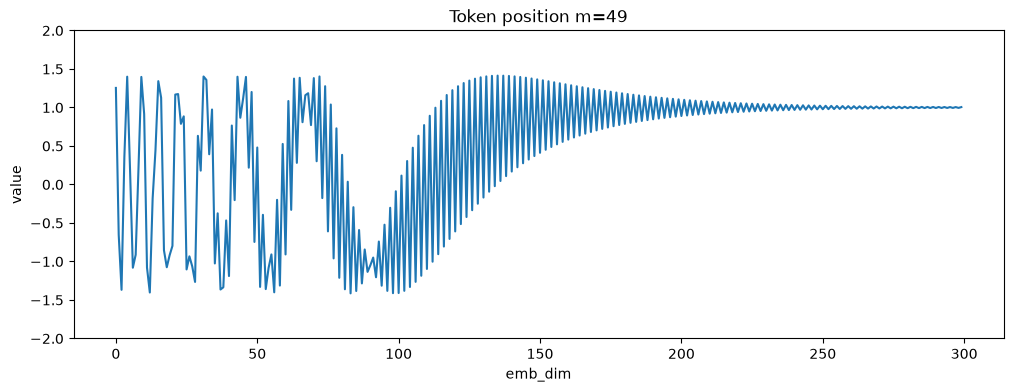

In [52]:
# AI generated vvvvvvv

fig, ax = plt.subplots(figsize=(12, 4))
line, = ax.plot(rope_x[0].numpy())
title = ax.set_title('Token position m=0')
ax.set_ylim(-2, 2)
ax.set_xlabel('emb_dim')
ax.set_ylabel('value')

def update(frame):
    line.set_ydata(rope_x[frame].numpy())
    title.set_text(f'Token position m={frame}')
    return line, title

ani = animation.FuncAnimation(fig, update, frames=T, interval=15, blit=True)
ani = animation.FuncAnimation(fig, update, frames=T, interval=150, blit=True)
ani.save('rope.gif', writer='pillow', fps=100)


In [3]:
l = [500, 20, 30, 40]
for i in range(len(l)):
    print(f"{i} : {sum(l[:i])}")

0 : 0
1 : 500
2 : 520
3 : 550


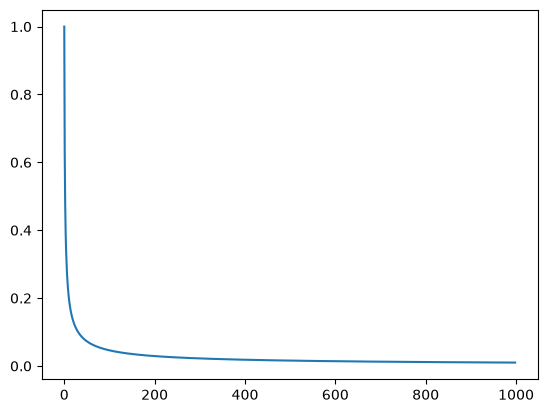

In [7]:
x = np.arange(1, 1000, 1)
y = x**(-2/3)
plt.plot(y)
plt.show()

In [10]:
import torch
m = torch.arange(1, 13, dtype=torch.bfloat16).view(3, 4)
identity = torch.tensor([[1, 0, 0],
                         [0, 1, 0], 
                         [0, 1, 0], 
                         [0, 0, 1]], dtype=torch.bfloat16)
print(f"{m}\n * \n\n{identity}\n=\n")

print(m @ identity)


tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.]], dtype=torch.bfloat16)
 * 

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], dtype=torch.bfloat16)
=

tensor([[ 1.,  5.,  4.],
        [ 5., 13.,  8.],
        [ 9., 21., 12.]], dtype=torch.bfloat16)
